# LIBRAIRIES

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from nucleo.io.reading import checking_parameters
from nucleo.io.reading import reading_one_parquet
from nucleo.io.reading import finding_one_parquet
from nucleo.io.reading import reading_all_parquet

# DATA : READING

In [2]:
root_i = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-16/nucleo__actifull__0/algo=2S__fact=True__mode=actifull__dstr=False__land=homogen__s=35__l=10__bpmin=0__mu=150__theta=25__rcapt=1.7e-01__rrest=1.7e-01__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__Ktot=1.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__"
df_i = reading_one_parquet(root_i)
print(df_i.columns)


root_j = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-04-17/nucleo__lshigh__46/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=150__bpmin=0__mu=540__theta=75__rcapt=1.7e-01__rrest=1.7e-01__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__Ktot=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__"
df_j = reading_one_parquet(root_j)
print(df_j.columns)

['algo', 'fact', 'mode', 'dstr', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'Ktot', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'vc_mp', 't_matrix', 'x_matrix', 'results', 'obstacles', 's_points', 's_distrib', 'l_points', 'l_distrib', 'l_view', 'p', 'results_mean', 'results_med', 'results_std', 'pos_hist', 'xbj_points', 'xbj_distrib', 'tbj_points', 'tbj_distrib', 'fpt_distrib', 'fpt_number', 'dx_points', 'dx_distrib', 'dx_mean', 'dx_med', 'dx_mp', 'dt_points', 'dt_distrib', 'dt_mean', 'dt_med', 'dt_mp', 'vi_points', 'vi_distrib', 'vc_points', 'vc_distrib', 'alpha0', 'xt_over_t', 'G', 'bound_low', 'bound_high']
['algo', 'fact',

In [3]:
# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Reading NUCLEO
root_nucleo = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-04-17"
df_all_nucleo = reading_all_parquet(root_nucleo)
print(df_all_nucleo.shape)
print(df_all_nucleo.columns)

# Params NUCLEO
params_all_nucleo = checking_parameters(df_all_nucleo)
print(params_all_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Reading FACT
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-16"
df_all_fact = reading_all_parquet(root_fact)
print(df_all_fact.shape)
print(df_all_fact.columns)

# Params FACT
params_all_fact = checking_parameters(df_all_fact)
print(params_all_fact)


# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_all_nucleo.columns == df_all_fact.columns:
    print("\n# ──  Ready for study ── #")

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:147: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


(131300, 60)
['algo', 'fact', 'mode', 'dstr', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'Ktot', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'dx_mean', 'dx_med', 'dx_mp', 'dt_mean', 'dt_med', 'dt_mp', 'alpha0', 'bound_low', 'bound_high']
{'algo': ['1S'], 'fact': [False], 'mode': ['none'], 'dstr': [False], 'landscape': ['homogen', 'periodic', 'random'], 's': [150], 'l': [5, 10, 15, 20, 25, 50, 100, 150], 'bpmin': [0, 5, 10, 15], 'mu': [100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 

In [7]:
# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Params
params_single_nucleo = {
    "algo"      : "1S",
    "fact"      : False,
    "mode"      : "none",
    "dstr"      : False, 
    "land"      : "homogen",
    "s"         : 150,
    "l"         : 10,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "alphar"    : 0.00,
    "Kp"        : 0.00,
    "Kz"        : 0.00
}

# Reading
df_single_nucleo = finding_one_parquet(root=root_nucleo, params=params_single_nucleo)
print(df_single_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Params
params_fact = {
    **params_single_nucleo,
    "algo"      : "2S",
    "fact"      : True,
    "mode"      : "passfull",
    "s"         : 35,
    "l"         : 35,
}

# Reading
df_single_fact = finding_one_parquet(root=root_fact, params=params_fact)
print(df_single_fact)

# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_single_nucleo.columns == df_single_fact.columns:
    print("\n# ──  Ready for study ── #")

['algo', 'fact', 'mode', 'dstr', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'Ktot', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'vc_mp', 't_matrix', 'x_matrix', 'results', 'obstacles', 's_points', 's_distrib', 'l_points', 'l_distrib', 'l_view', 'p', 'results_mean', 'results_med', 'results_std', 'pos_hist', 'xbj_points', 'xbj_distrib', 'tbj_points', 'tbj_distrib', 'fpt_distrib', 'fpt_number', 'dx_points', 'dx_distrib', 'dx_mean', 'dx_med', 'dx_mp', 'dt_points', 'dt_distrib', 'dt_mean', 'dt_med', 'dt_mp', 'vi_points', 'vi_distrib', 'vc_points', 'vc_distrib', 'alpha0', 'xt_over_t', 'G', 'bound_low', 'bound_high']
Scanning 131300 

In [ ]:
# ── CHECK ──────────────────────────────────────────────────────────────────────



# ────────────────────────────────────────────────────────────────────── A faire quand je récupère les resultats avec land au lieu de landscape ────────────────────────────────────────────────────────────────────── #



# if df_all_nucleo.columns == df_all_fact.columns:
#     print("\n# ──  Ready for study ── #")


def check_sim_parameters(df_all: pl.DataFrame, params: dict) -> bool:
    # Build AND filter chain from all key-value pairs
    conditions = [pl.col(key) == value for key, value in params.items()]

    # conditions sur landscape
    
    combined = conditions[0]
    for cond in conditions[1:]:
        combined = combined & cond
    
    df_verif = df_all.filter(combined)
    
    is_valid = df_verif.shape[0] > 0
    
    if is_valid:
        print(f"Valid configuration — {df_verif.shape[0]} matching row(s) found")
    else:
        print("Invalid configuration — does not exist in dataset")
    
    return is_valid


check_sim_parameters(df_all=df_all_nucleo, params=params_single_nucleo)

[<Expr ['[(col("algo")) == ("1S")]'] at 0x79BFBC663050>, <Expr ['[(col("fact")) == (false)]'] at 0x79BF5FE230B0>, <Expr ['[(col("mode")) == ("none")]'] at 0x79BF5FE23DA0>, <Expr ['[(col("dstr")) == (false)]'] at 0x79BF5FE21FA0>, <Expr ['[(col("land")) == ("homogen")]'] at 0x79BF5FE36C00>, <Expr ['[(col("s")) == (dyn int: 150)]'] at 0x79BF5FE34650>, <Expr ['[(col("l")) == (dyn int: 10)]'] at 0x79BF5FE36DB0>, <Expr ['[(col("bpmin")) == (dyn int: 0…'] at 0x79BF5FE368A0>, <Expr ['[(col("mu")) == (dyn int: 150)…'] at 0x79BF5FE37230>, <Expr ['[(col("theta")) == (dyn int: 1…'] at 0x79BF5FE36D50>, <Expr ['[(col("alphar")) == (dyn float…'] at 0x79BF5FE36E10>, <Expr ['[(col("Kp")) == (dyn float: 0)…'] at 0x79BF5FE36BA0>, <Expr ['[(col("Kz")) == (dyn float: 0)…'] at 0x79BF5FE37140>]


ColumnNotFoundError: unable to find column "land"; valid columns: ["algo", "fact", "mode", "dstr", "landscape", "s", "l", "bpmin", "mu", "theta", "alphaf", "alphao", "beta", "rcapt", "rrest", "alphac", "alphad", "alphar", "Ktot", "Kp", "Kz", "c_linker", "c_nucleo", "Lmin", "Lmax", "bps", "origin", "tmax", "dt", "binx", "bint", "nt", "s_mean", "l_mean", "alpha_mean_v", "alpha_mean_c", "v_mean", "v_med", "v_mean_th", "v_mean_th_eff", "vf", "Cf", "wf", "vf_std", "Cf_std", "wf_std", "vi_mean", "vi_med", "vi_mp", "vc_mean", "vc_med", "dx_mean", "dx_med", "dx_mp", "dt_mean", "dt_med", "dt_mp", "alpha0", "bound_low", "bound_high"]

# DATA : CHECKING

[nucleo] alpha_mean_v = 0.0625
[fact] alpha_mean_v = 0.5


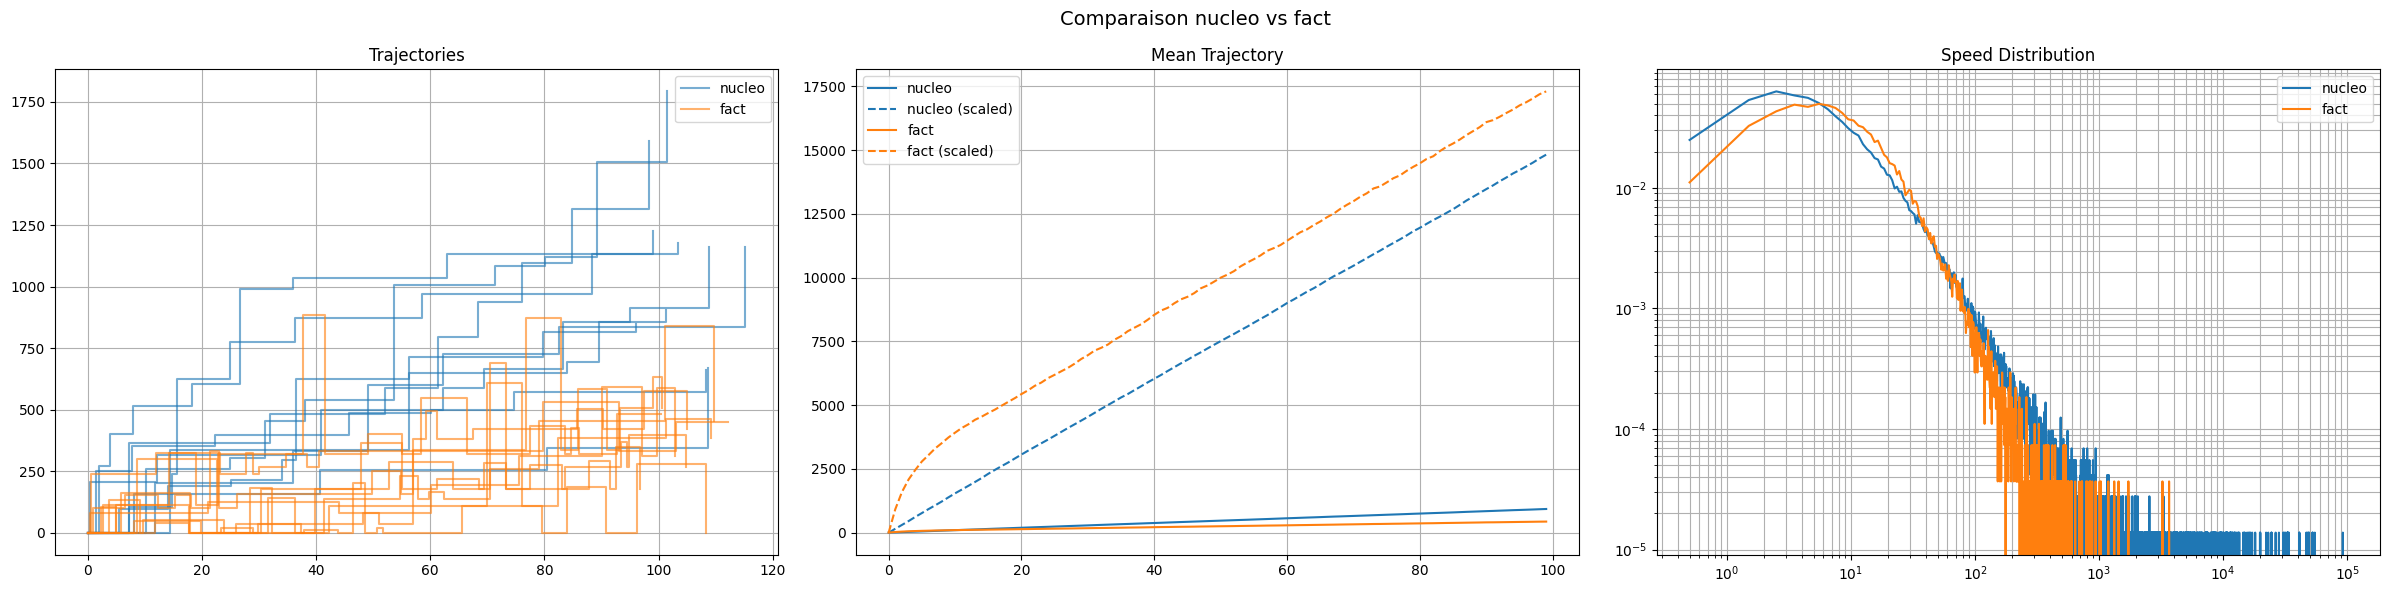

In [5]:
def plot_df_main_info(dfs: list[tuple[pl.DataFrame, str]], title: str = "") -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(24, 6))
    if title:
        fig.suptitle(title, fontsize=14)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, (df, label) in enumerate(dfs):
        color = colors[idx % len(colors)]

        # --- Trajectories ---
        x1 = df["t_matrix"][0].to_numpy()
        y1 = df["x_matrix"][0].to_numpy()
        for i in range(10):
            ax1.plot(x1[i], y1[i], drawstyle="steps-mid", color=color,
                     alpha=0.6, label=label if i == 0 else None)

        # --- Mean Trajectory ---
        x2 = df["times"][0].to_numpy()
        y2 = df["results_mean"][0].to_numpy()
        alpha_mean_v = df["alpha_mean_v"][0]
        print(f"[{label}] alpha_mean_v = {alpha_mean_v}")
        ax2.plot(x2, y2, color=color, label=label)
        if "nucleo" in label:
            ax2.plot(x2, y2 / alpha_mean_v, color=color,
                     linestyle="--", label=f"{label} (scaled)")
        elif "fact" in label:
            alphac = df["alphac"][0]
            rrest  = df["rrest"][0]
            rcapt  = df["rcapt"][0]
            ax2.plot(x2, y2 * (1/rrest + 1/rcapt) / alpha_mean_v / (alphac),
                     color=color, linestyle="--", label=f"{label} (scaled)")

        # --- Speed Distribution ---
        x3 = df["vi_points"][0].to_numpy()
        y3 = df["vi_distrib"][0].to_numpy()
        ax3.loglog(x3, y3, color=color, label=label)

    ax1.set_title("Trajectories")
    ax1.legend()
    ax1.grid(True, which="both")

    ax2.set_title("Mean Trajectory")
    ax2.legend()
    ax2.grid(True, which="both")

    ax3.set_title("Speed Distribution")
    ax3.legend()
    ax3.grid(True, which="both")

    plt.tight_layout()
    plt.show()

plot_df_main_info(
    dfs=[(df_single_nucleo, "nucleo"), (df_single_fact, "fact")],
    title="Comparaison nucleo vs fact"
)

# DATA : MULTI

In [11]:
# ── ADDING COLUMNS ──────────────────────────────────────────────────────────────────────

# Copying the file
df_all = (df_all_fact.clone())
print(df_all)

# Adding R
df_all = df_all.with_columns(
    (pl.col("Kp") * pl.col("alphar")).alias("R")
)

# Calculation of v_mean_R0 and wf_R0
v_mean_R0 = df_all.filter(pl.col("Kp") == 0)["v_mean"].mean()
wf_R0     = df_all.filter(pl.col("Kp") == 0)["wf"].mean()

# Adding Gv and Gw
df_all = df_all.with_columns(
    (pl.col("v_mean") / v_mean_R0).alias("Gv"),
    (pl.col("wf")     / wf_R0).alias("Gw")
)

# Printing
print(df_all)

shape: (143_748, 60)
┌──────┬──────┬──────────┬───────┬───┬───────┬────────┬───────────┬────────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dt_mp ┆ alpha0 ┆ bound_low ┆ bound_high │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---    ┆ ---       ┆ ---        │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ i64    ┆ i64       ┆ i64        │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪════════╪═══════════╪════════════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 6.5   ┆ 1      ┆ 5         ┆ 80         │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 5.5   ┆ 1      ┆ 5         ┆ 80         │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 4.5   ┆ 1      ┆ 5         ┆ 80         │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 5.5   ┆ 1      ┆ 5         ┆ 80         │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 5.5   ┆ 1      ┆ 5         ┆ 80         │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …      ┆ …         ┆ …          │
│ 2S   ┆ true ┆ passmemo ┆ false ┆ … ┆ 5.5   ┆ 1      ┆ 5         ┆ 80         │
│ 2S   

In [21]:
# ── SELECTING PARAMETERS ──────────────────────────────────────────────────────────────────────

# Values
s     = 35
l     = 10
bpmin = 0
mu    = 150
theta = 100
Kz    = 0

# Dict
params_fixed = {
    "fact"      : True,
    "algo"      : "2S",
    "s"         : s,
    "l"         : l,
    "bpmin"     : bpmin,
    "mu"        : mu,
    "theta"     : theta,
    "Kz"        : Kz     # Checking that is doesn't affect while null 
}

# Filter Function
def filter_df(df: pl.DataFrame, params: dict) -> pl.DataFrame:
    """Filtre df sur les clés/valeurs de params, en ignorant les valeurs None."""
    filters = [pl.col(k) == v for k, v in params.items() if v is not None]
    return df.filter(pl.all_horizontal(filters)) if filters else df

# DataFrame
df_work = filter_df(df_all, params_fixed)
print(df_work)

# Parameters Non Fixed
Kps     = np.unique(df_work["Kp"])
modes   = np.unique(df_work["mode"])
lands   = np.unique(df_work["landscape"])

# Prints
print(f"lands = {lands}")
print(f"modes = {modes}")
print(f"Kps   = {Kps}")

shape: (1_452, 63)
┌──────┬──────┬──────────┬───────┬───┬────────────┬─────┬──────────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ bound_high ┆ R   ┆ Gv       ┆ Gw       │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---        ┆ --- ┆ ---      ┆ ---      │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ i64        ┆ f64 ┆ f64      ┆ f64      │
╞══════╪══════╪══════════╪═══════╪═══╪════════════╪═════╪══════════╪══════════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 80         ┆ 0.0 ┆ 0.464569 ┆ 0.87592  │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 80         ┆ 0.0 ┆ 0.461752 ┆ 0.876579 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 80         ┆ 0.0 ┆ 0.460214 ┆ 0.844892 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 80         ┆ 0.0 ┆ 0.461065 ┆ 0.786393 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 80         ┆ 0.0 ┆ 0.453934 ┆ 0.871686 │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …          ┆ …   ┆ …        ┆ …        │
│ 2S   ┆ true ┆ passmemo ┆ false ┆ … ┆ 80         ┆ 0.6 ┆ 1.43395  ┆ 1.143549 │
│ 2S   ┆ true ┆ passm

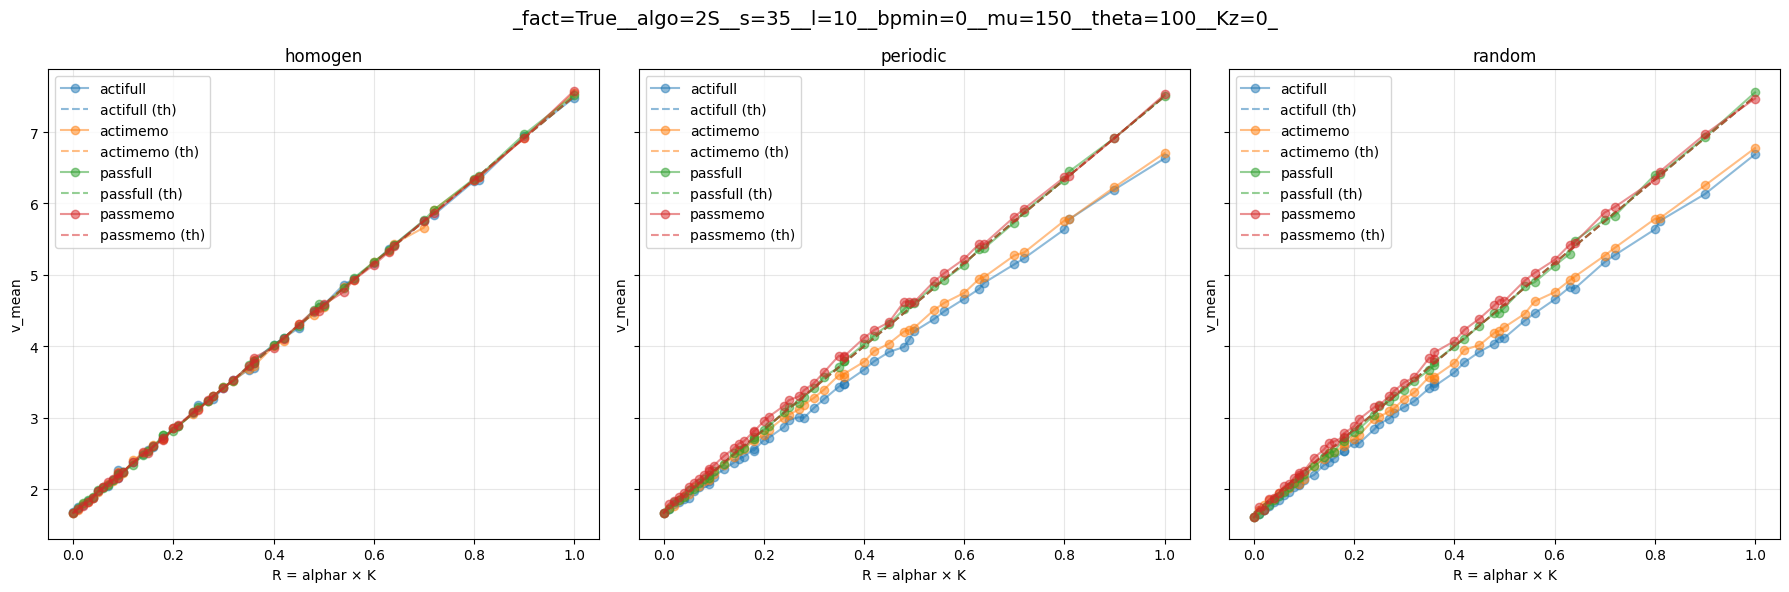

In [ ]:
# ── Scenarios in function of K and modes ──────────────────────────────────────────────────────────────────────
n_landscapes = len(lands)
fig, axes = plt.subplots(ncols=n_landscapes, nrows=1, figsize=(6 * n_landscapes, 6), sharey=True)

if n_landscapes == 1:
    axes = [axes]

title = ""
for key, value in params_fixed.items():
     title += f"_{key}={value}_"
plt.suptitle(title, fontsize=14)


for ax, landscape in zip(axes, lands):
    df_land = df_work.filter(pl.col("landscape") == landscape)

    ax.set_title(landscape)
    
    for mode in modes:
            df_solo = (
                df_land
                .filter(pl.col("mode") == mode)
                .group_by("R")
                .agg([
                    pl.col("v_mean").mean(),
                    pl.col("v_mean_th").mean(),
                ])
                .sort("R")
            )
            R      = df_solo["R"].to_numpy()
            v      = df_solo["v_mean"].to_numpy()
            v_th   = df_solo["v_mean_th"].to_numpy()

            line, = ax.plot(R, v,    label=mode, marker="o", alpha=0.5)
            ax.plot(        R, v_th, label=f"{mode} (th)",
                    linestyle="--", color=line.get_color(), marker="", alpha=0.5)

    ax.set_xlabel("R = alphar × K")
    ax.set_ylabel("v_mean")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

plt.tight_layout()
plt.show()

In [19]:
# --- Colonne R + filtres ---
df_work = (
    df_all.clone()
    .with_columns((pl.col("Kp") * pl.col("alphar")).alias("R"))
    .filter(
        (pl.col("l")     == l)     &
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta)
    )
)

# --- Moyenne de v_mean par (factmode, landscape, R) ---
df_agg = (
    df_work
    .group_by(["mode", "landscape", "R"])
    .agg(pl.col("v_mean").mean())
    .sort(["mode", "landscape", "R"])
)

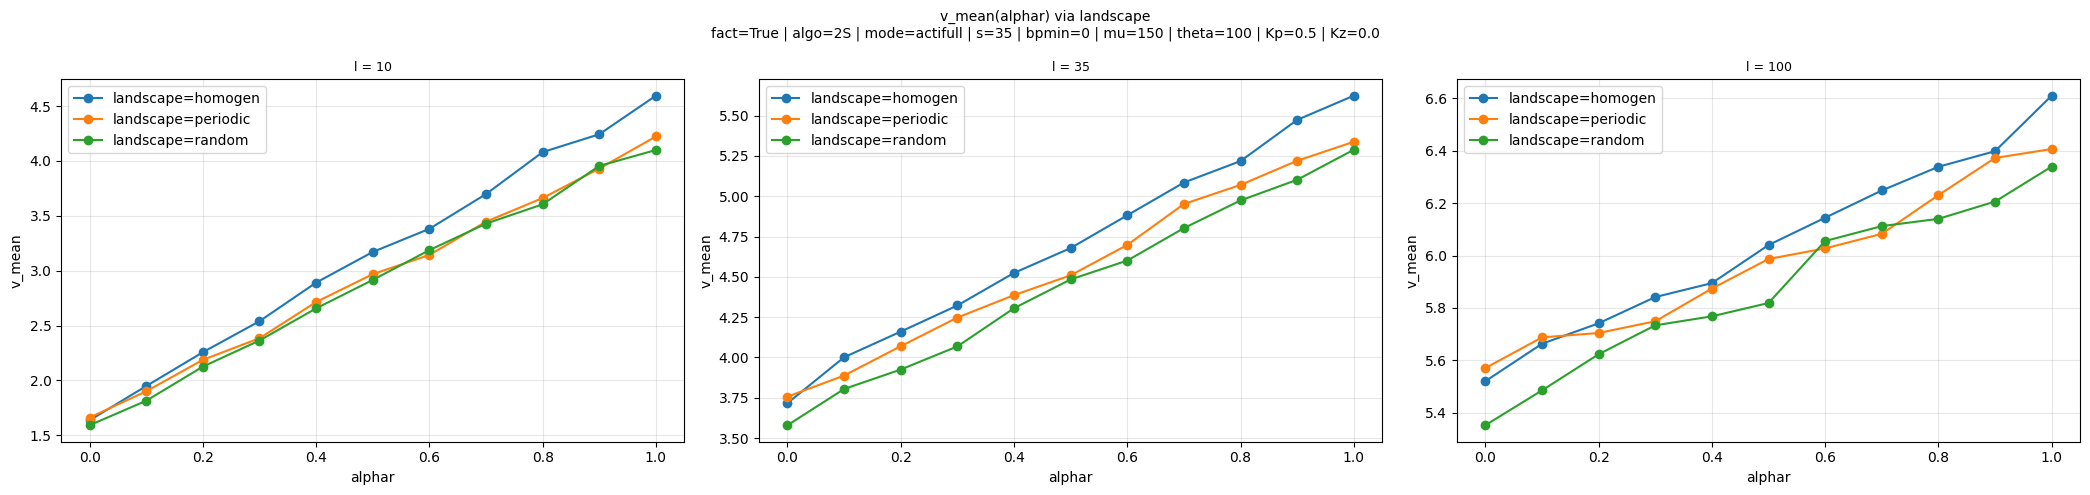

In [ ]:
def plot_fact_data(
    df        : pl.DataFrame,
    x         : str,
    y         : str,
    param     : str,
    fixed     : dict = {},
    ax        : plt.Axes = None,
    title     : str = None,
    marker    : str = "o",
) -> plt.Axes:
    """
    Trace y(x) pour chaque valeur de `param`, les autres paramètres étant fixés.

    Args:
        df     : DataFrame source (df_all)
        x      : colonne pour l'axe X
        y      : colonne pour l'axe Y
        param  : colonne dont on fait varier les valeurs (une courbe par valeur)
        fixed  : dict {colonne: valeur} des paramètres à fixer via filtre
        ax     : axes matplotlib existant (sinon en crée un nouveau)
        title  : titre du graphique (auto-généré si None)
        marker : marqueur matplotlib
    """
    # Filtrage
    filters = [pl.col(k) == v for k, v in fixed.items() if v is not None]
    df_filtered = df.filter(pl.all_horizontal(filters)) if filters else df

    # Axe
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    # Une courbe par valeur de param
    for val in sorted(df_filtered[param].unique().to_list()):
        df_solo = df_filtered.filter(pl.col(param) == val).sort(x)
        ax.plot(df_solo[x].to_numpy(), df_solo[y].to_numpy(), label=f"{param}={val}", marker=marker)

    # Titre auto si non fourni
    if title is None:
        fixed_str = " | ".join(f"{k}={v}" for k, v in fixed.items() if v is not None)
        title = f"{y}({x})  —  par {param}" + (f"\n{fixed_str}" if fixed_str else "")

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    return ax


# Multi
x     = "alphar"
y     = "v_mean"
param = "landscape"
vary  = "l"

ls = sorted(df_all[vary].unique().to_list())
fig, axes = plt.subplots(ncols=len(ls), nrows=1, figsize=(7*len(ls), 5))

fixed_base = {
    "fact"      : True,
    "algo"      : "2S",
    "mode"      : "actifull",
    "s"         : 35,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "Kp"        : 0.50,
    "Kz"        : 0.00      # Meaning no contribution from the fact to beeing dynamic
}

for ax, l_val in zip(axes, ls):
    plot_fact_data(
        df    = df_all,
        x     = x,
        y     = y,
        param = param,
        fixed = {**fixed_base, "l": l_val},
        ax    = ax,
        title = f"l = {l_val}",
    )

suptitle_str = " | ".join(f"{k}={v}" for k, v in fixed_base.items())
plt.suptitle(f"{y}({x}) via {param}\n{suptitle_str}", fontsize=10)
plt.tight_layout()
plt.show()

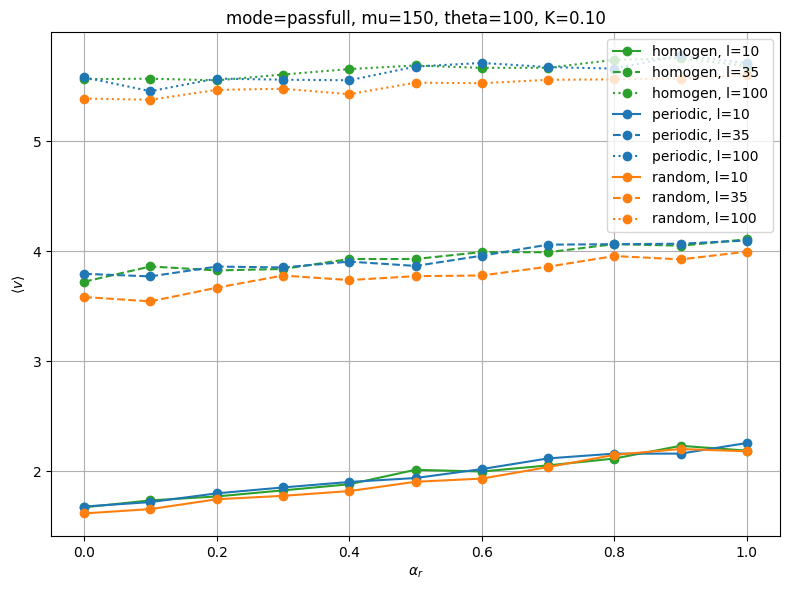

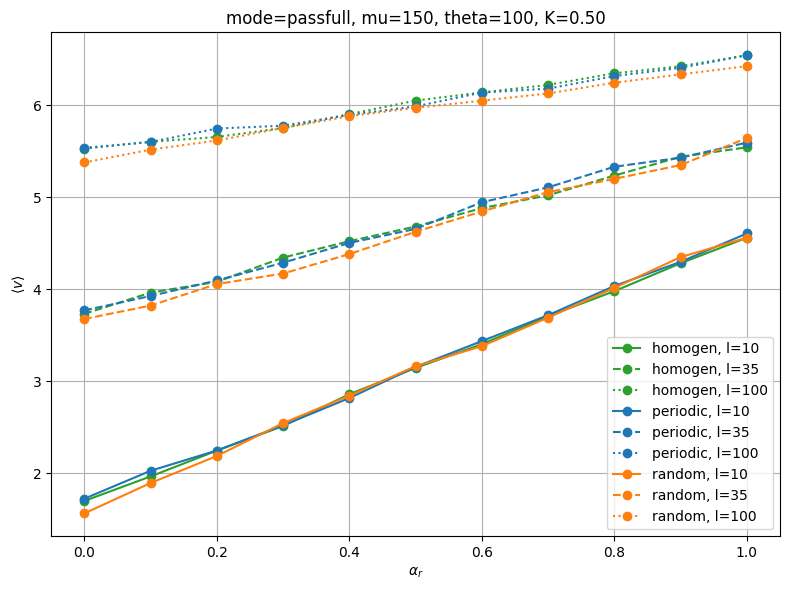

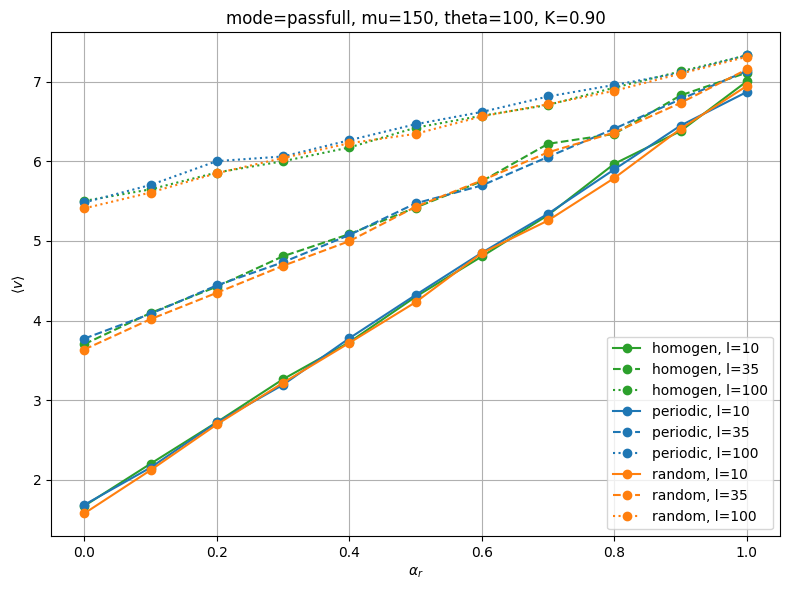

In [30]:
from itertools import product

# Couleurs par landscape
landscape_colors = {
    "periodic"    : "tab:blue",
    "random"      : "tab:orange",
    "homogen"     : "tab:green",
}

# Styles par l (ordonnés)
ls_sorted  = np.sort(ls)
linestyles = {
    ls_sorted[0]: "-",
    ls_sorted[1]: "--",
    ls_sorted[2]: ":",
}

def plot_vmean_vs_alphar(df_all, value, mode, Kp, Kz, title):
    plt.figure(figsize=(8, 6))
    plt.title(title)

    landscapes = np.unique(df_all["landscape"].to_numpy())

    for landscape, l in product(landscapes, ls):
        df_data = df_all.filter(
            (pl.col("mode")      == mode) &
            (pl.col("landscape") == landscape) &
            (pl.col("l")         == l)         &
            (pl.col("mu")        == mu) &
            (pl.col("theta")     == theta) &
            (pl.col("Kp").is_close(Kp)) &
            (pl.col("Kz").is_close(Kz))
        )
        if df_data.height == 0:
            continue

        alphar  = df_data["alphar"].to_numpy()
        to_plot = df_data[value].to_numpy()

        plt.plot(
            alphar, to_plot,
            color     = landscape_colors[landscape],
            linestyle = linestyles[l],
            marker    = "o",
            label     = f"{landscape}, l={l}",
        )

    plt.xlabel(r"$\alpha_r$")
    plt.ylabel(r"$\langle v \rangle$")
    # plt.ylim([-1, 10])
    plt.grid(True)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

value = "v_mean"
mode = "passfull"
plot_vmean_vs_alphar(df_all, value=value, mode=mode, Kp=0.10, Kz=0.00, title=f"mode={mode}, mu={mu}, theta={theta}, K=0.10")
plot_vmean_vs_alphar(df_all, value=value, mode=mode, Kp=0.50, Kz=0.00, title=f"mode={mode}, mu={mu}, theta={theta}, K=0.50")
plot_vmean_vs_alphar(df_all, value=value, mode=mode, Kp=0.90, Kz=0.00, title=f"mode={mode}, mu={mu}, theta={theta}, K=0.90")

# DATA : Heatmaps

['algorithm', 'fact', 'factmode', 'destroy', 'landscape', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'alphac', 'alphad', 'rtot_capt', 'rtot_rest', 'alphar', 'K', 'ktot', 'kB', 'kU', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'dx_mean', 'dx_med', 'dx_mp', 'dt_mean', 'dt_med', 'dt_mp', 'alpha0', 'bound_low', 'bound_high']
{'algorithm': ['two_steps'], 'fact': [True], 'factmode': ['active_full', 'active_memory', 'passive_full', 'passive_memory'], 'destroy': [False], 'landscape': ['homogeneous', 'periodic', 'random'], 's': [35], 'l': [10, 35, 100], 'bpmin': [0], 'mu': [150], 'theta': [20, 90], 'alphar': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0], 'K': [0.0, 0.1, 0.2, 0

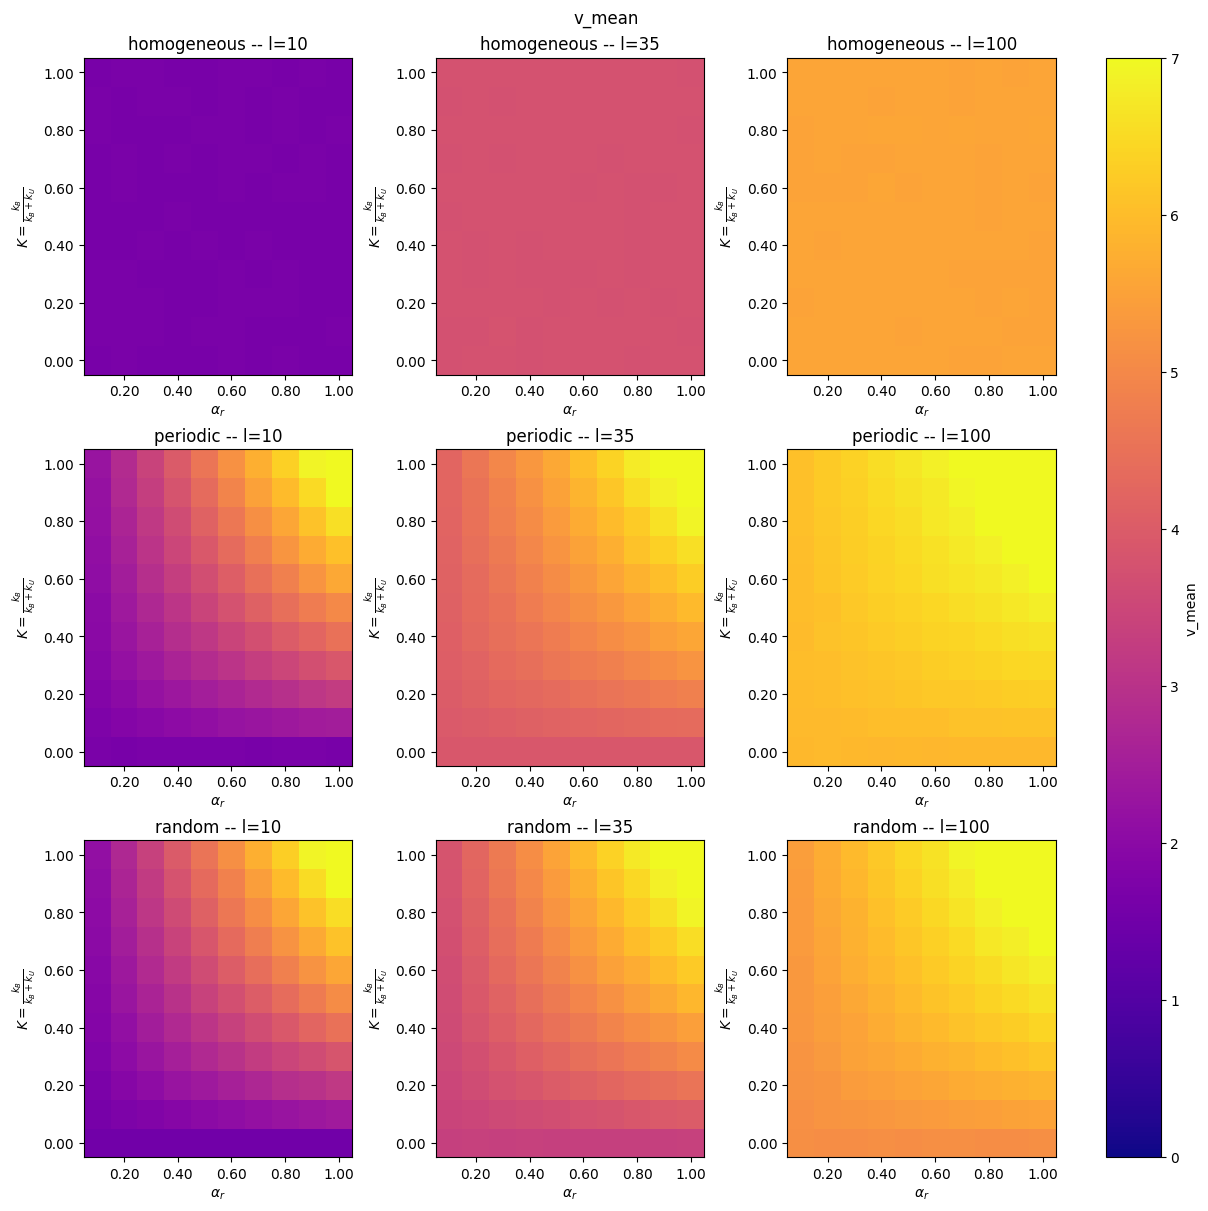

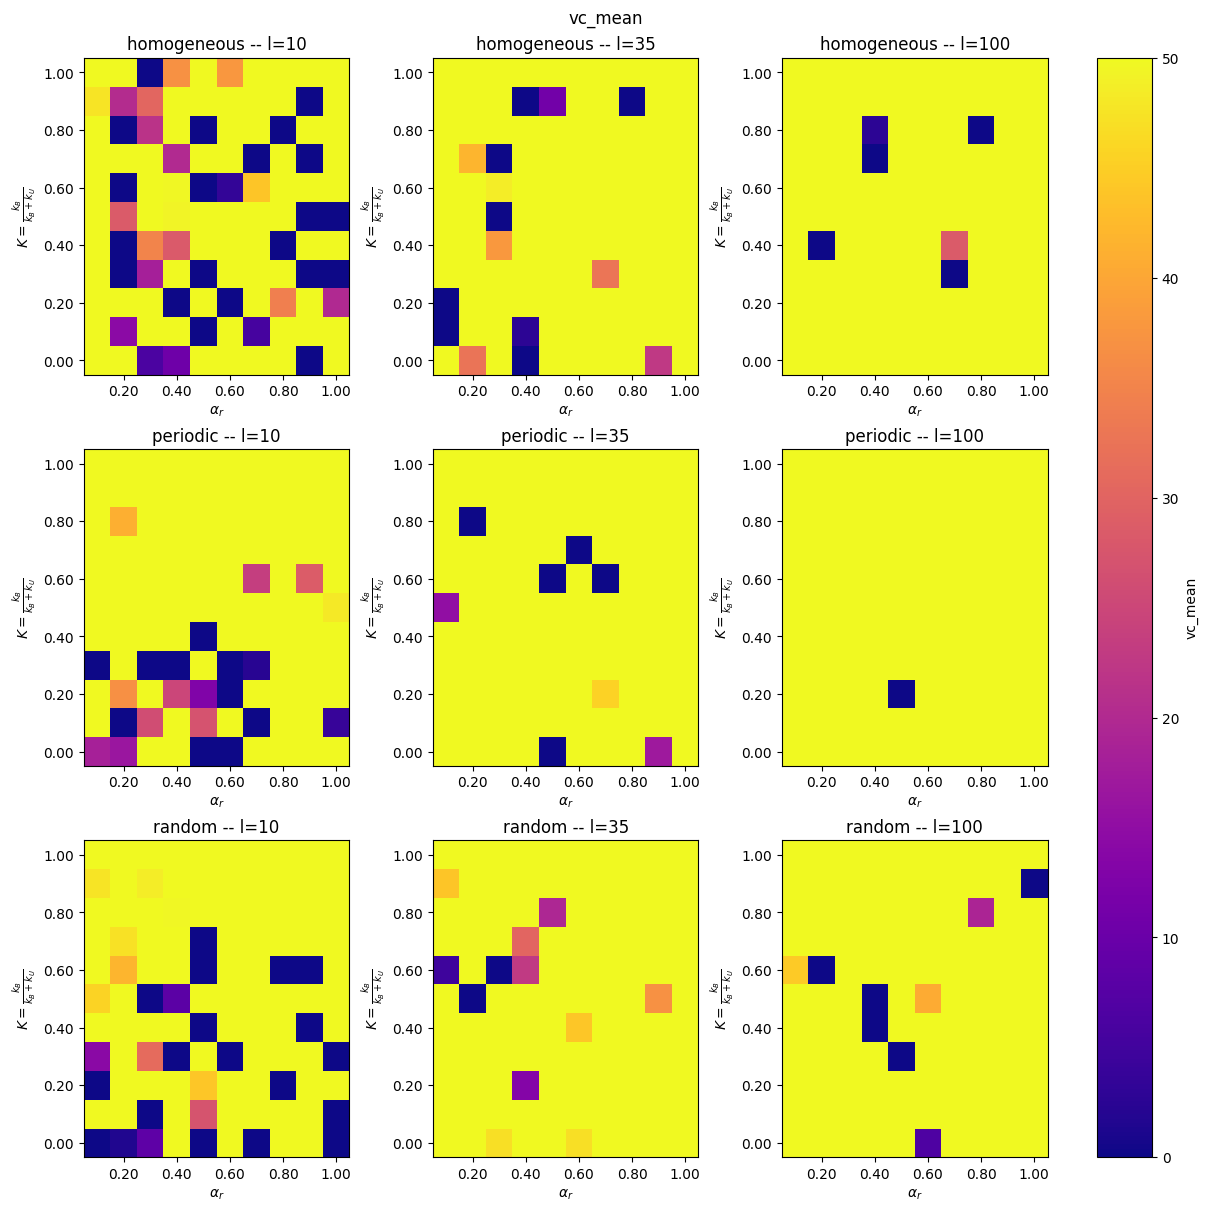

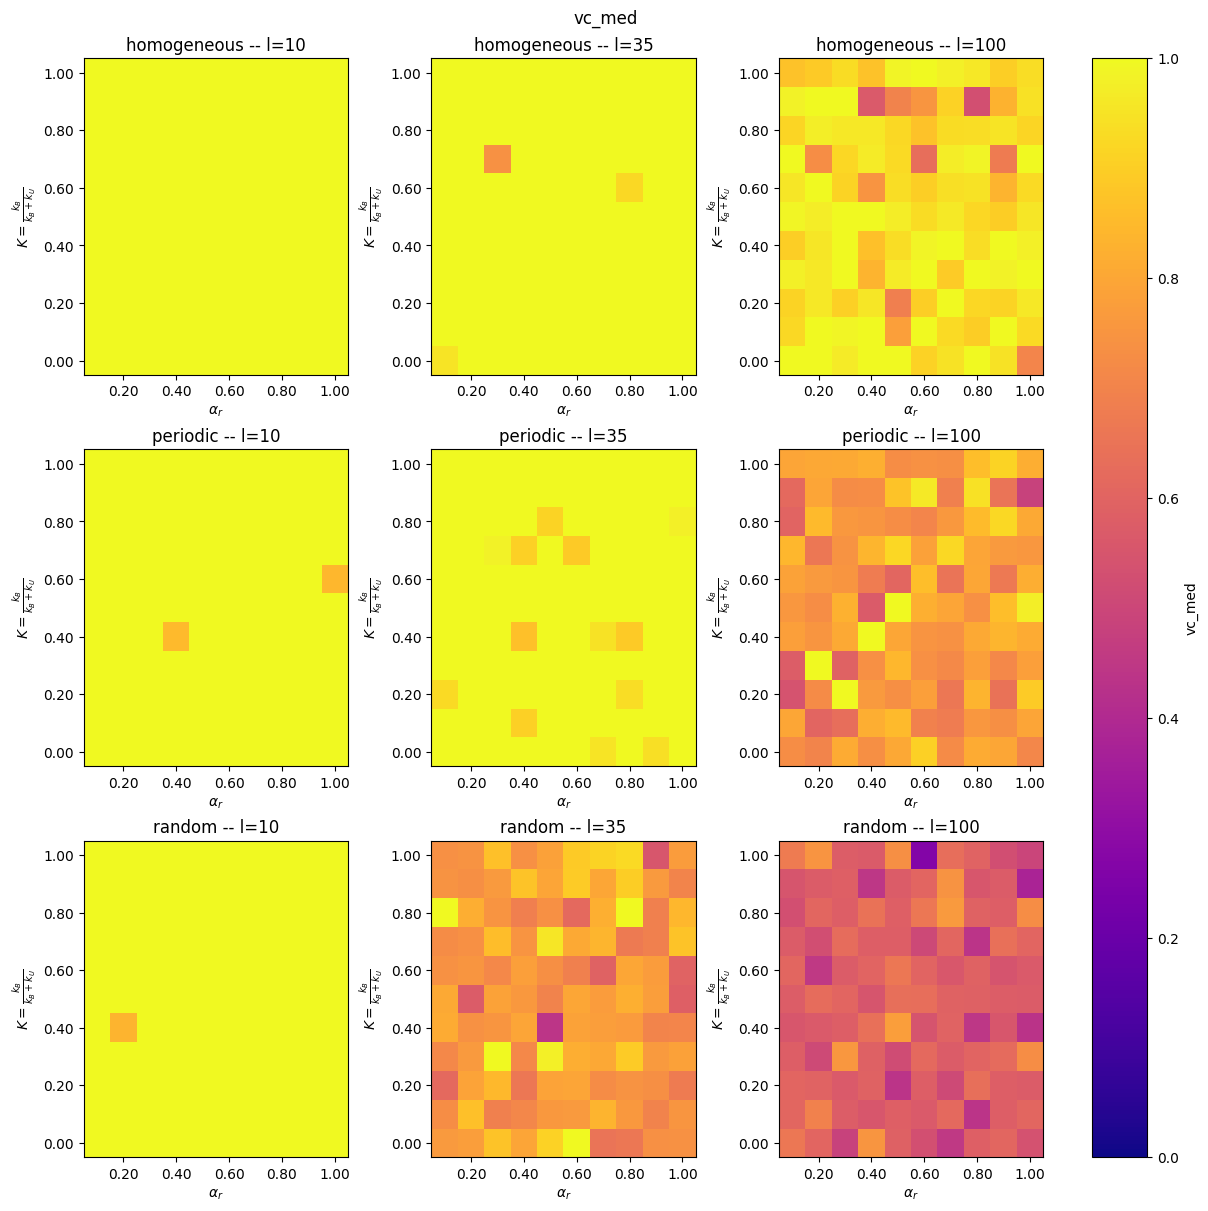

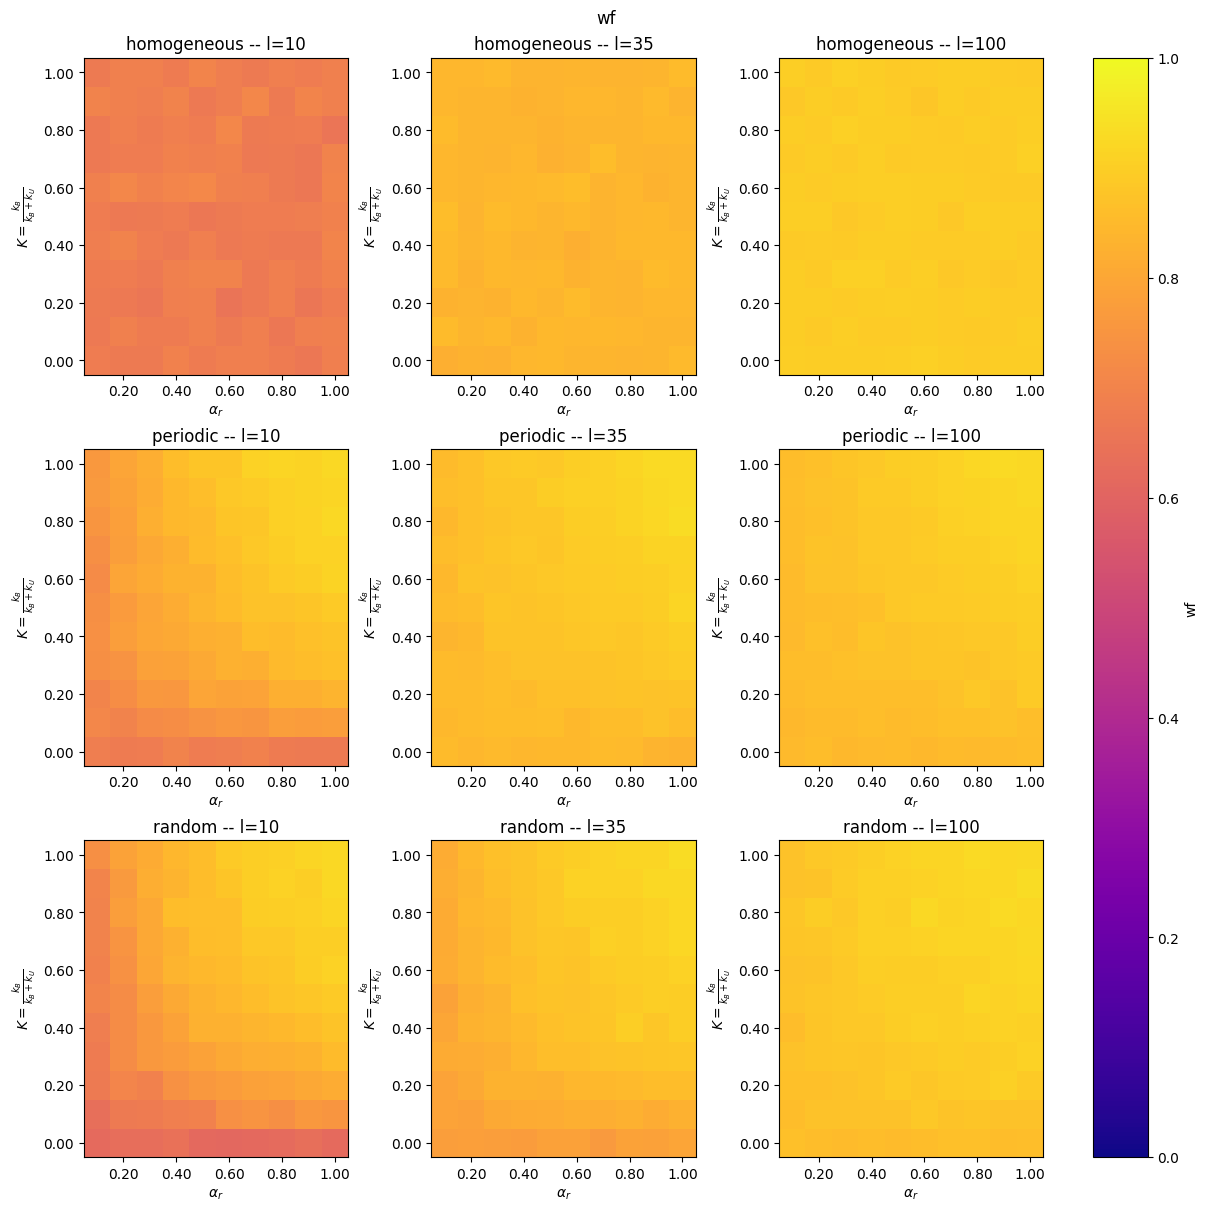

In [ ]:
from itertools import product
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def plot_single_heatmap(
    df: pl.DataFrame,
    landscape: str,
    l: int,
    value: str,
    ax,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given landscape and l.
    """
    # 1) Filtrage (alphar = 0 exclu)
    df_heat = (
        df.filter(
            (pl.col("landscape") == landscape) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "K", value])
        .sort(["K", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{landscape} -- l={l}\n(no data)")
        return None

    # 2) Pivot 100% Polars → pas besoin de pandas
    pivot_pl = (
        df_heat
        .group_by(["K", "alphar"])
        .agg(pl.col(value).mean())
        .sort(["K", "alphar"])
        .pivot(on="alphar", index="K", values=value)
        .sort("K")
    )

    # Extraction des axes et de la grille
    Y = pivot_pl["K"].to_numpy()                          # lignes  (K)
    X = np.array(                                          # colonnes (alphar)
        sorted(float(c) for c in pivot_pl.columns if c != "K")
    )
    col_order = [str(x) for x in X]                       # ordre cohérent
    Z2D = pivot_pl.select(col_order).to_numpy().astype(float)

    X_grid, Y_grid = np.meshgrid(X, Y)

    # 3) Scale (lin / log)
    if log_plot:
        Z2D = np.log2(Z2D)
        vmin, vmax = -2, 2
    else:
        if value == "v_mean":
            vmin, vmax = 0, 7
        elif value == "vc_mean":
            vmin, vmax = 0, 50
        elif value == "vc_med":
            vmin, vmax = 0, 1
        elif value =="wf":
            vmin, vmax = 0, 1
        else:
            vmin, vmax = None, None

    # 4) Plot
    c = ax.pcolormesh(
        X_grid, Y_grid, Z2D,
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"{landscape} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K = \frac{k_B}{k_B + k_U}$")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c


def plot_heatmaps(df_all: pl.DataFrame, value: str, cmap: str = "plasma"):
    """Trace les heatmaps pour toutes les combinaisons (landscape, l)."""
    landscapes = sorted(df_all["landscape"].unique().to_list())
    ls = sorted(df_all["l"].unique().to_list())

    n_rows = len(landscapes)
    n_cols = len(ls)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )
    axes_2d = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(value)

    last_c = None
    for i, landscape in enumerate(landscapes):
        for j, l in enumerate(ls):
            c = plot_single_heatmap(df_all, landscape, l, value, axes_2d[i, j], cmap=cmap)
            if c is not None:
                last_c = c

    if last_c is not None:
        fig.colorbar(last_c, ax=axes_2d.ravel().tolist(), orientation='vertical', label=value)

    plt.show()


# ── Chargement ───────────────────────────────────────────────────────────────
df_all = reading_all_parquet(root_data)
print(df_all.columns)

params_sim = checking_parameters(df_all)
print(params_sim)

# ── Visualisations ───────────────────────────────────────────────────────────
for value in ["v_mean", "vc_mean", "vc_med", "wf"]:
    plot_heatmaps(df_all, value)

# THEN :

In [37]:
# ── Calcul des colonnes de référence ─────────────────────────────────────────
# Vitesse de référence = v_mean pour landscape="homogeneous"
df_ref = (
    df_all
    .filter(pl.col("landscape") == "homogeneous")
    .select(["alphar", "K", "l", "v_mean"])
    .rename({"v_mean": "v_ref"})
)

# Join sur les clés communes
df_all = (
    df_all
    .join(df_ref, on=["alphar", "K", "l"], how="left")
    .with_columns([
        (pl.col("v_mean") - pl.col("v_ref")).alias("v_diff"),
        (pl.col("v_mean") / pl.col("v_ref")).alias("v_ratio"),
    ])
)

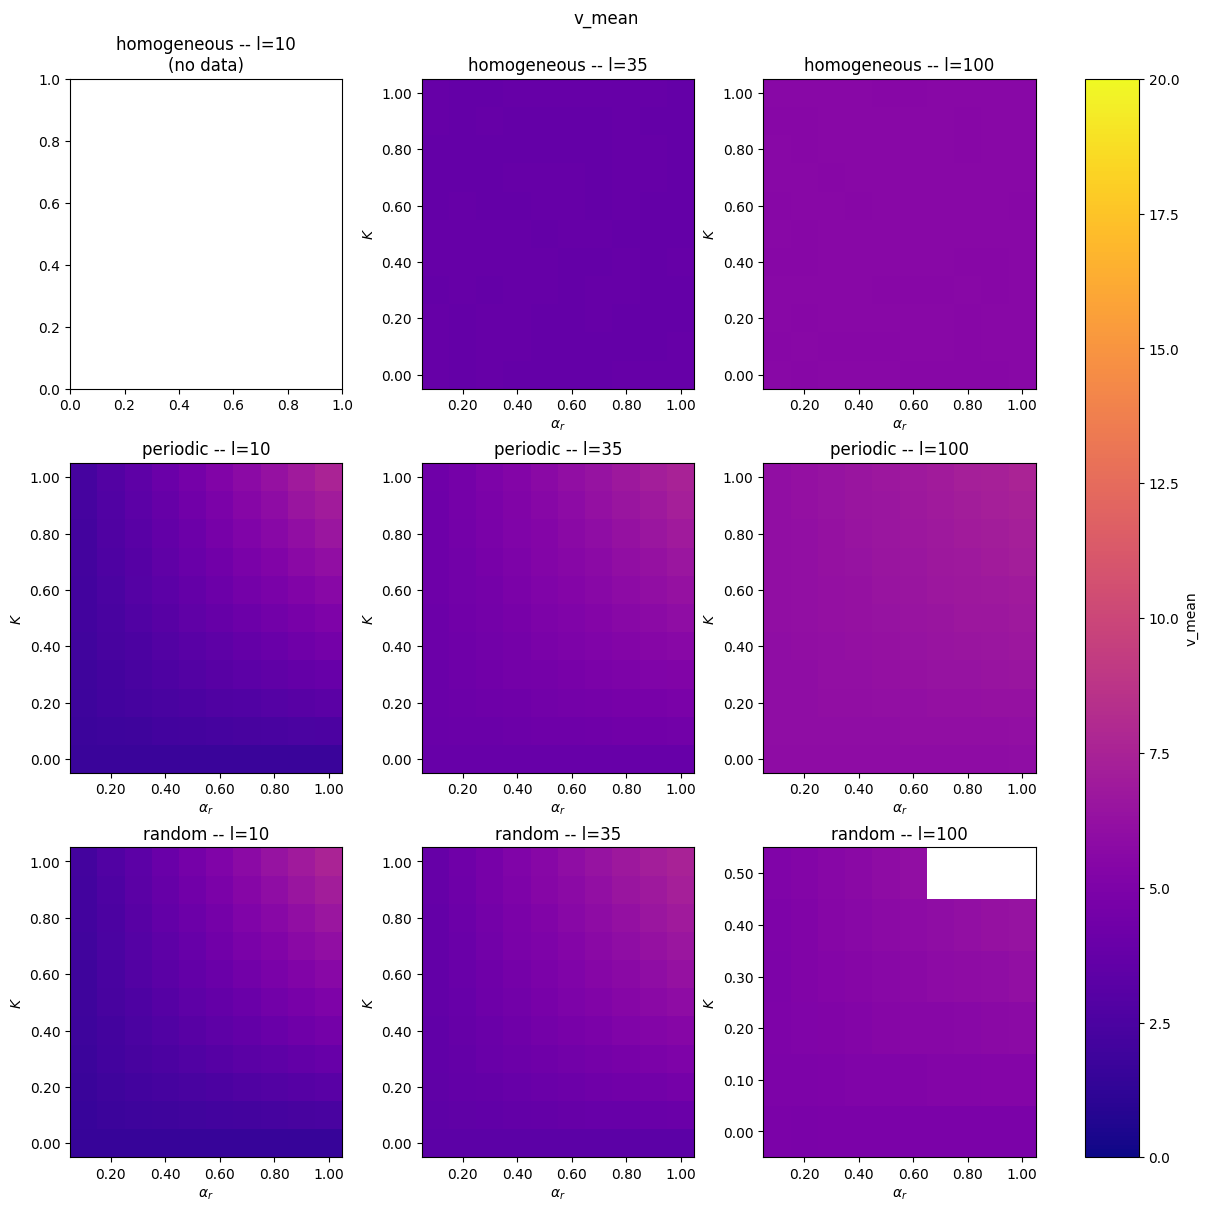

ColumnNotFoundError: unable to find column "v_diff"; valid columns: ["algorithm", "fact", "factmode", "landscape", "s", "l", "bpmin", "mu", "theta", "alphaf", "alphao", "beta", "lmbda", "alphad", "rtot_capt", "rtot_rest", "alphar", "K", "ktot", "kB", "kU", "c_linker", "c_nucleo", "Lmin", "Lmax", "bps", "origin", "tmax", "dt", "binx", "bint", "nt", "s_mean", "l_mean", "alpha_mean_v", "alpha_mean_c", "v_mean", "v_med", "v_mean_th", "v_mean_th_eff", "vf", "Cf", "wf", "vf_std", "Cf_std", "wf_std", "vi_mean", "vi_med", "vi_mp", "vc_mean", "vc_med", "dx_mean", "dx_med", "dx_mp", "dt_mean", "dt_med", "dt_mp", "alpha0", "bound_low", "bound_high"]

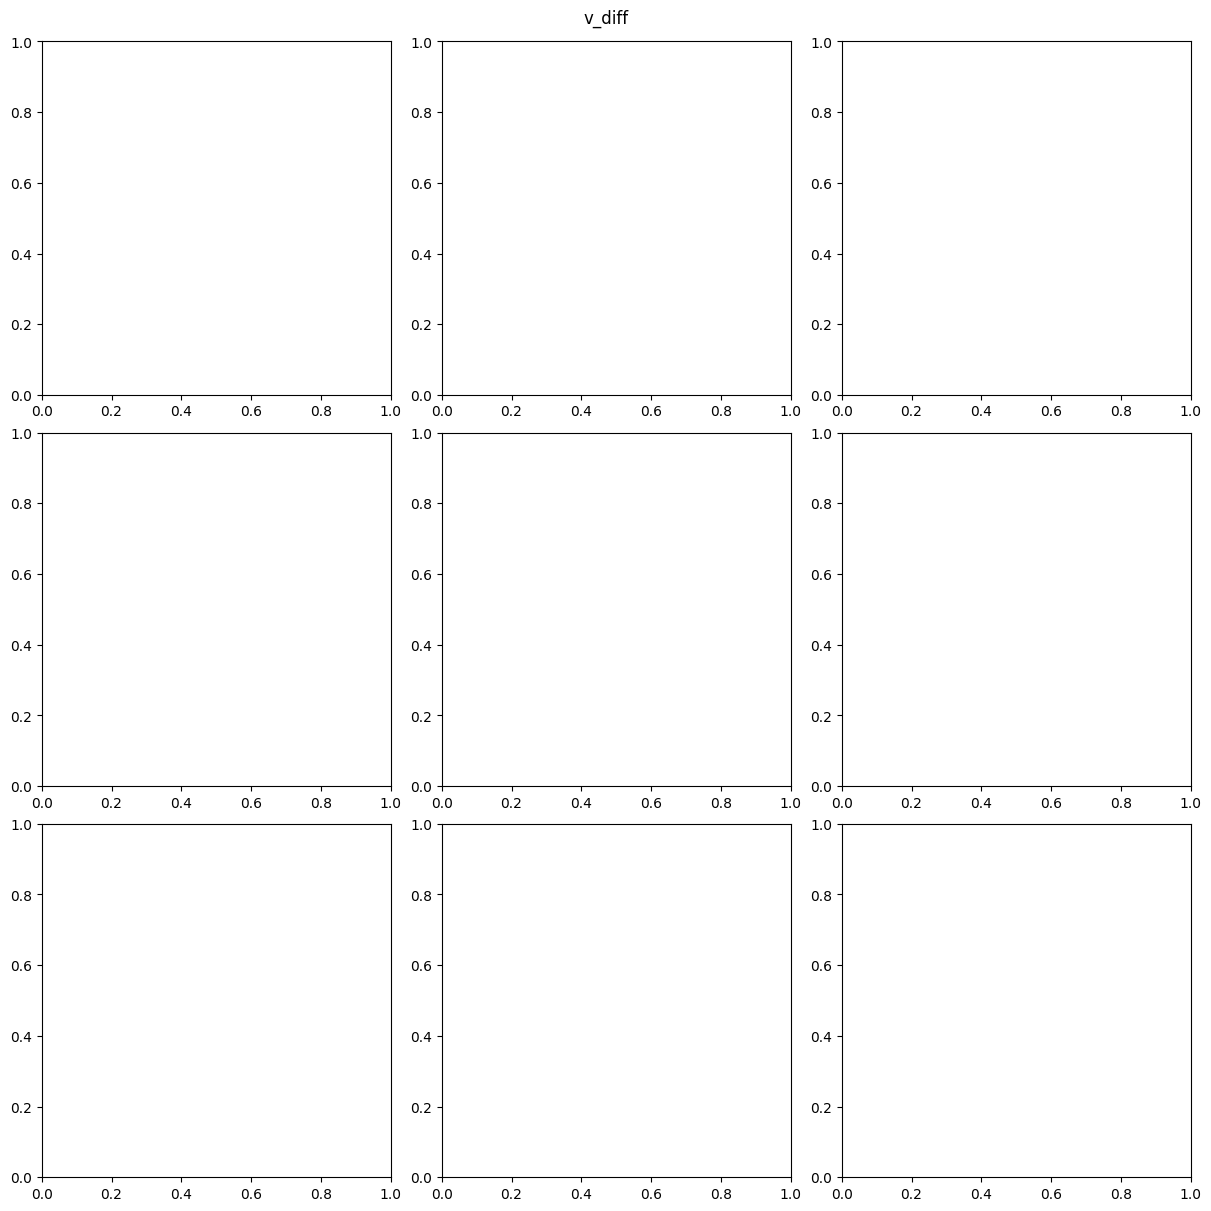

In [19]:
import matplotlib.ticker as mticker

def plot_single_heatmap(
    df: pl.DataFrame,
    landscape: str,
    l: int,
    value: str,
    ax,
    vmin: float = 0.0,
    vmax: float = 10.0,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given landscape and l.
    """

    # 1) Consistent filtering (alphar = 0 is removed at the source)
    df_heat = (
        df.filter(
            (pl.col("landscape") == landscape) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "K", value])
        .sort(["K", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{landscape} -- l={l}\n(no data)")
        return None

    # 2) Pivot → the grid comes from the pivot (source of truth)
    pivot = df_heat.pivot(values=value, index="K", on="alphar", aggregate_function="mean")
    pivot = pivot.sort("K")

    Y = pivot["K"].to_numpy()
    X = np.sort(np.array([c for c in pivot.columns if c != "K"], dtype=float))
    Z2D = pivot.select([str(x) for x in X]).to_numpy()

    X_grid, Y_grid = np.meshgrid(X, Y)

    # 3) Scale (lin / log)
    if log_plot:
        Z2D = np.log2(Z2D)
        vmin, vmax = -2, 2
        label = rf"$\log_2({value})$"
    else:
        label = value
        if value == "v_mean":
            vmin, vmax = 0, 20
        elif value == "v_diff":
            vmin, vmax = 0, 10
        elif value == "v_ratio":
            vmin, vmax = 1, 2
    # ... (identique jusqu'au plot)

    # 3) Scale
    if log_plot:
        Z2D   = np.log2(Z2D)
        vmin, vmax = -2, 2
        label = rf"$\log_2({value})$"
    else:
        label = value

    # 4) Plot
    c = ax.pcolormesh(X_grid, Y_grid, Z2D, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(f"{landscape} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K$")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c



for value, vmin, vmax in [("v_mean", 0, 20), ("v_diff", -10, 10), ("v_ratio", 0, 3), ("wf", 0, 1)]:

    n_rows = len(landscapes)
    n_cols = len(ls)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), constrained_layout=True)
    axes_flat = axes.flatten() if axes.ndim > 1 else axes
    plt.suptitle(value)

    for ax, (landscape, l) in zip(axes_flat, product(landscapes, ls)):
        c = plot_single_heatmap(df_all, landscape, l, value, ax, vmin=vmin, vmax=vmax)

    fig.colorbar(c, ax=axes_flat, orientation='vertical', label=value)
    plt.show()

---- Observations ----

K joue un rôle plus important que alphar : on peut supposer que c'est la fréquence d'un repliement même léger qui jour un rôle plus important que son déroulement total

Plus le linker est petit plus la différence est importante : des facteurs de transcription efficaces en fréquences permettent à des chromatines denses d'être extrudées vite

Le remodellage aide plus dans les cas aléatoires que dans les cas périodiques

# .